In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from auxPlots import iso_contours_unstructured
import json
# Cosmetics:
import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

### Create dataframe with all results

In [2]:
# Load combined json file (created with collectData.py)
jsonFile = '../ATLAS-SUSY-2018-14_displacedLeptons/atlas_susy_2018_14_HeHe_scan.json'
with open(jsonFile, 'r') as f:
    data = json.load(f)

columns = list(data[0].keys())
# Expand efficiencies for all lifetimes
dfRecast = pd.json_normalize(
    data,
    meta=columns
)

dfRecast['tau0_ns'] = (dfRecast['tau0_ns']).apply(lambda x: float(f'{x:.2e}'))
dfRecast['width_GeV'] = 6.582e-16/dfRecast['tau0_ns']
dfRecast['yDM'] = dfRecast['frblock_2'] # l-F-s coupling
dfRecast['mDM'] = dfRecast['m5000022'] # DM (s) mass

## Plot Exclusion in ms vs y

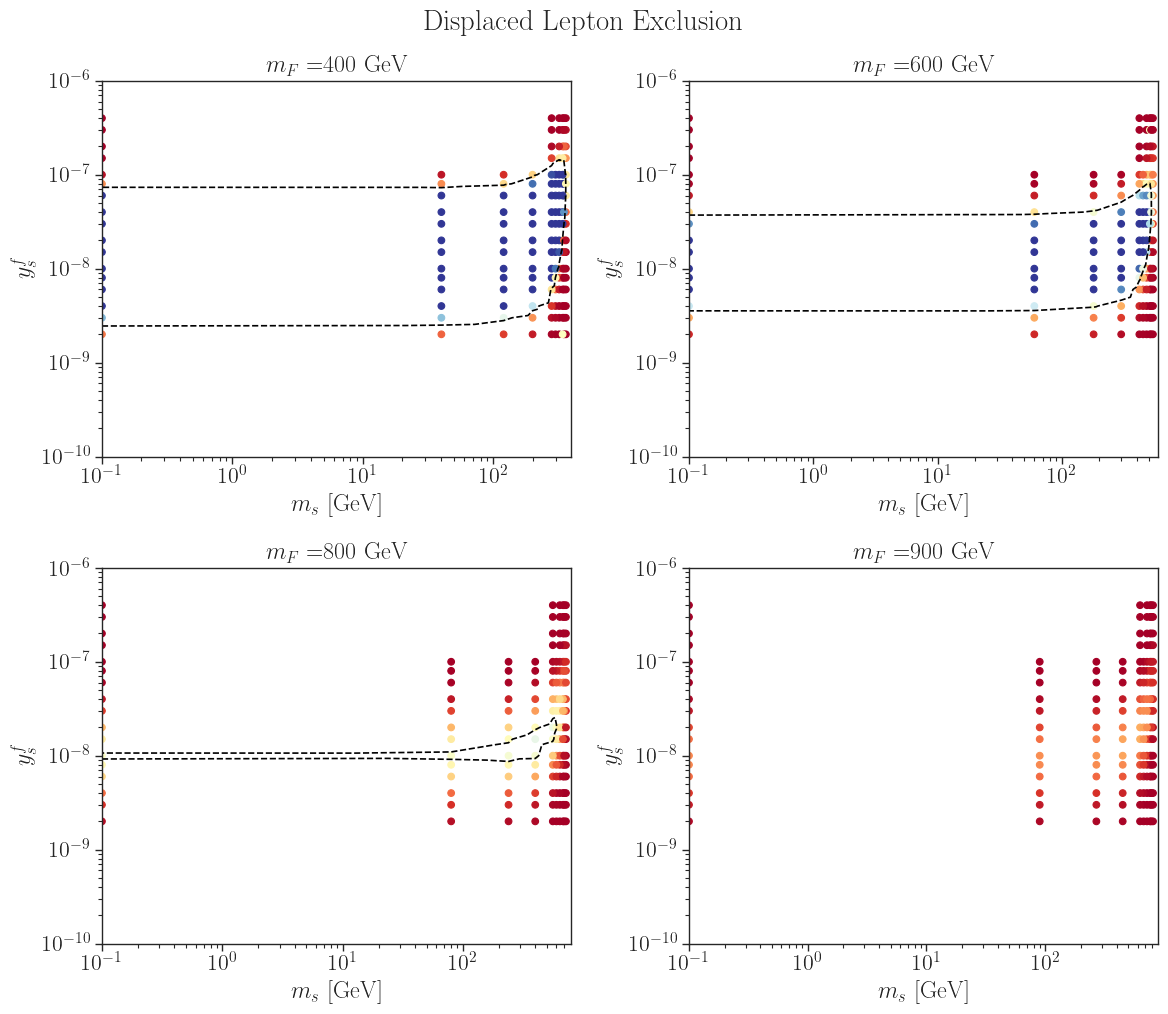

In [ ]:
fig,axes =plt.subplots(figsize=(12,10),nrows=2,ncols=2)

title = r'$p p \to F F,\, F \to s + l$'
mFList = [400.,600.,800.,900.]



for iax,ax in enumerate(axes.flat):
    mF = mFList[iax]
     # Select points with fixed mF
    df = dfRecast[dfRecast['mLLP'] == mF]
    x = df['mDM'].to_numpy()
    y = df['yDM'].to_numpy()
    title = r'$m_F = $' + f'{mF:1.0f} GeV'
    r = 1.0/df['muUL_observed'].to_numpy()

    im = ax.scatter(x,y,c=r,cmap=cm,vmin=0,vmax=2)

    contours = iso_contours_unstructured(x,y,r,z0=1.0,logy=True)
    if len(contours) > 0:
        contours = sorted(contours, key=lambda c: len(c), reverse=True)
        contour = contours[0]
        np.savetxt(f'contour_DL_mF{mF:1.0f}GeV.txt', contour, header='ms [GeV], yDM')
        ax.plot(contour[:,0], contour[:,1], color='black', linestyle='--')

    ax.set_xlabel(r'$m_{s}$ [GeV]')
    ax.set_ylabel(r'$y_{s}^f$')
    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlim(1e-1,mF-5.0)
    ax.set_ylim(1e-10,1e-6)
    ax.set_title(title)
    # ax.set_xticks(np.arange(0.,mF,50.))
    # ax.grid(True, which='both', ls='--', lw=0.5)

plt.tight_layout()
plt.suptitle('Displaced Lepton Exclusion', y=1.02)
plt.show()

## Plot Exclusion in mF vs y

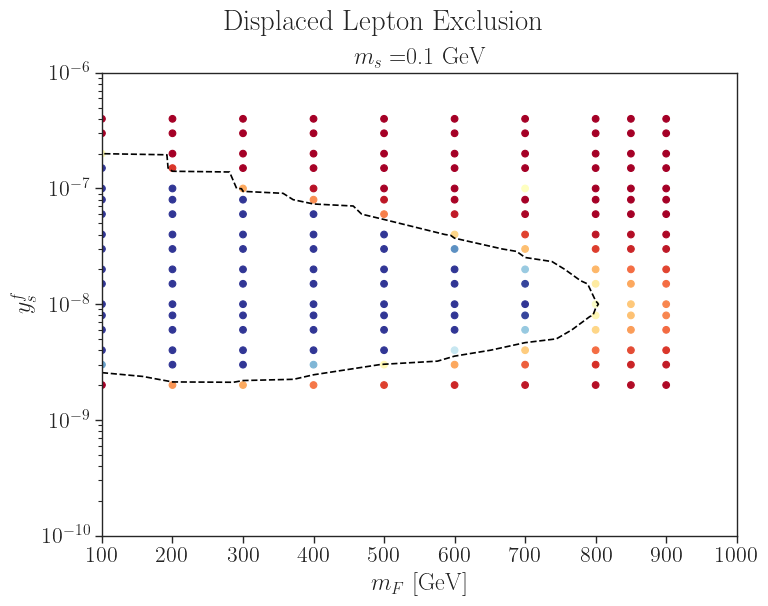

In [ ]:
fig,ax =plt.subplots(figsize=(8,6),nrows=1,ncols=1)

title = r'$p p \to F F,\, F \to s + l$'
ms = 0.1



    # Select points with fixed mF
df = dfRecast[dfRecast['mDM'] == ms]
x = df['mLLP'].to_numpy()
y = df['yDM'].to_numpy()
title = r'$m_s = $' + f'{ms:1.1f} GeV'
r = 1.0/df['muUL_observed'].to_numpy()

im = ax.scatter(x,y,c=r,cmap=cm,vmin=0,vmax=2)

contours = iso_contours_unstructured(x,y,r,z0=1.0,logy=True)
if len(contours) > 0:
    contours = sorted(contours, key=lambda c: len(c), reverse=True)
    contour = contours[0]
    np.savetxt(f'contour_DL_ms{ms:1.1f}GeV.txt', contour, header='mF [GeV], yDM')
    ax.plot(contour[:,0], contour[:,1], color='black', linestyle='--')

ax.set_xlabel(r'$m_{F}$ [GeV]')
ax.set_ylabel(r'$y_{s}^f$')
ax.set_yscale('log')
# ax.set_xscale('log')
ax.set_xlim(100.0,1000.0)
ax.set_ylim(1e-10,1e-6)
ax.set_title(title)

plt.tight_layout()
plt.suptitle('Displaced Lepton Exclusion', y=1.02)
plt.show()